In [1]:
import pathlib
from os import path, getcwd, chdir

import numpy as np
from tqdm import tqdm

chdir(r'C:\Users\IanFu\Desktop\~1_CURRENT\efsprapy\01-analysis\case_study_solve_upa')


def read_data(parent_dir: pathlib.Path) -> (list, list):
    folders = [item for item in parent_dir.iterdir() if item.is_dir()]
    folders.sort()
    protected_areas = list()
    failure_prob = list()
    for folder in tqdm(folders):
        protected_area = float(folder.name.split('-')[1])
        fp_output = folder / f'{folder.name}_out.csv'
        try:
            assert path.exists(fp_output), f'file does not exist {fp_output}'
        except AssertionError:
            continue
        mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)

        N = np.shape(mcs_output)[0]

        # find all iterations that ignition occurred
        t_ig_ftp = mcs_output[:, 2]
        P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / N

        protected_areas.append(protected_area*100)
        failure_prob.append(P_ig)
    return protected_areas, failure_prob


data = {
    'Unsprinklered':read_data(pathlib.Path(getcwd(), 'unsprinklered')),
    # br187_sprinkler=read_data(pathlib.Path(getcwd(), 'br187_sprinkler')),
    'Sprinklered (CFAST)': read_data(pathlib.Path(getcwd(), 'sprinklered_cfast')),
}

100%|██████████| 10/10 [00:00<00:00, 509.68it/s]


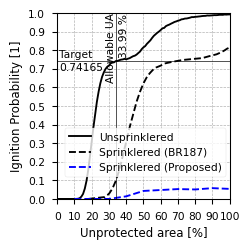

In [4]:
from fsetools.lib.fse_thermal_radiation import phi_parallel_any_br187
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=96)

ax.set_xlabel("Unprotected area [%]")
ax.set_ylabel("Ignition Probability [1]")
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
lines = dict()
lines['Unsprinklered'] = ax.plot(*data['Unsprinklered'], label='Unsprinklered', c='k')
y__ = np.linspace(0, 1, 100)
x__ = np.interp(y__, data['Unsprinklered'][1], data['Unsprinklered'][0])
lines['Sprinklered (BR187)'] = ax.plot(x__*2, y__, label='Sprinklered (BR187)', c='k', ls='--')
lines['Sprinklered (CFAST)'] = ax.plot(*data['Sprinklered (CFAST)'], label='Sprinklered (Proposed)', c='b', ls='--')

ax.legend(loc='center left', bbox_to_anchor=(0.015, 0.25)).set_visible(True)

# target
x_ = 12.6 / (phi_parallel_any_br187(6, 3, 6 / 2, 3 / 2, 2.5) * 84) * 100  # unprotected area %
y_ = np.interp(x_, *data['Unsprinklered'])
line_color = lines['Unsprinklered'][0].get_color()
ax.axvline(x_, ls="-", color=line_color, lw=0.5)
ax.text(x_ + 2, 1, f"{x_:.2f} %", color=line_color, ha="left", va="top", rotation=90, fontsize=8)
ax.text(x_ - 0.05, 1, "Allowable UA", color=line_color, ha="right", va="top", rotation=90, fontsize=8)
ax.axhline(y_, ls="-", color=line_color, lw=0.5)
ax.text(1, y_ + 0.01, "Target", color=line_color, ha="left", va="bottom", fontsize=8)
ax.text(1, y_ - 0.01, f"{y_:.5f}", color=line_color, ha="left", va="top", fontsize=8)

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 100.1, 10))
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))

fig.tight_layout()

In [3]:
12.6 / (phi_parallel_any_br187(12, 3, 12 / 2, 3 / 2, 4) * 84)

0.4666335039582412